# Deep Learning

## Import Libraries

In [ ]:
!pip install tqdm Sastrawi

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
from gensim.models import Word2Vec, FastText
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional
from sklearn.model_selection import train_test_split

## Load Dataset & Preprocessing

In [ ]:
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
tqdm.pandas()

from google.colab import drive
drive.mount('/content/drive')

data_path = "/content/drive/MyDrive/Label_berita_New.csv"
df = pd.read_csv(data_path)

# Ambil kolom penting
df = df[['judul_berita', 'label']].dropna()
print("Data awal:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data awal: (5300, 2)


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())

USE_STEMMING = False   # bisa diganti True kalau mau stem

In [ ]:
def clean_text(text):
    text = str(text).lower()

    # hanya huruf
    text = re.sub(r'[^a-z\s]', ' ', text)

    # tokenisasi
    tokens = text.split()

    # hapus stopwords
    tokens = [w for w in tokens if w not in stopwords]

    # stemming (opsional)
    if USE_STEMMING:
        tokens = [stemmer.stem(w) for w in tokens]

    return " ".join(tokens)

In [ ]:
df['clean'] = df['judul_berita'].progress_apply(clean_text)

print("\nContoh hasil cleaning:")
print(df[['judul_berita', 'clean']].head())

100%|██████████| 5300/5300 [00:00<00:00, 86390.09it/s]


Contoh hasil cleaning:
                                        judul_berita  \
0  Video: Pemerintah Ungkap Potensi AI Sebagai Me...   
1  Dorong Ekonomi, Pemprov Jateng Beri Keringanan...   
2  Ekonom Minta Purbaya Lakukan Hal Ini Usai Guyu...   
3  Ahmad Labib Sebut Sinergi APBN hingga Pajak Do...   
4  Mengenal Sumitronomics, Konsep Ekonomi yang Di...   

                                               clean  
0  video pemerintah ungkap potensi ai mesin ekono...  
1  dorong ekonomi pemprov jateng beri keringanan ...  
2  ekonom minta purbaya lakukan usai guyur bank rp t  
3  ahmad labib sebut sinergi apbn hingga pajak do...  
4  mengenal sumitronomics konsep ekonomi disinggu...  


In [ ]:
label_mapping = {
    "Positif": 1,
    "Negatif": 0,
    "Netral": 2
}

df['label_num'] = df['label'].map(label_mapping)

# Cek apakah ada label yang tidak masuk mapping
missing = df['label_num'].isna().sum()
print("Label tidak dikenal:", missing)

# Buang label yang tidak dikenali
df = df.dropna(subset=['label_num'])

df['label_num'] = df['label_num'].astype(int)

print("\nJumlah data per kelas:")
print(df['label_num'].value_counts())

Label tidak dikenal: 0

Jumlah data per kelas:
label_num
2    2336
1    2223
0     741
Name: count, dtype: int64


In [ ]:
texts = df['clean'].astype(str).tolist()
labels = df['label_num'].tolist()

print("Total data:", len(texts))
print("Contoh teks:", texts[0])
print("Contoh label:", labels[0])

Total data: 5300
Contoh teks: video pemerintah ungkap potensi ai mesin ekonomi baru
Contoh label: 1


## Tokenizer & Padding

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

max_words = 30000      # maksimal jumlah kata dalam vocab
max_len = 50           # panjang sequence

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)

X = tokenizer.texts_to_sequences(texts)
X = pad_sequences(X, maxlen=max_len)

y = np.array(labels)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.16, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (4452, 50)
Test : (848, 50)


## Train Word2Vec + FastText Indo

In [ ]:
!pip install gensim
from gensim.models import Word2Vec

tokenized = [t.split() for t in texts]

w2v_dim = 100

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=w2v_dim,
    window=5,
    min_count=2,
    workers=4
)

print("Vocabulary size Word2Vec:", len(w2v_model.wv))

Vocabulary size Word2Vec: 3706


In [ ]:
embedding_matrix_w2v = np.zeros((max_words, w2v_dim))

for word, i in tokenizer.word_index.items():
    if i < max_words:
        if word in w2v_model.wv:
            embedding_matrix_w2v[i] = w2v_model.wv[word]

In [ ]:
!wget -q https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.vec.gz
!gunzip cc.id.300.vec.gz

In [ ]:
fasttext_path = "cc.id.300.vec"

ft_dim = 300
embedding_matrix_ft = np.zeros((max_words, ft_dim))

with open(fasttext_path, 'r', encoding='utf-8', errors='ignore') as f:
    next(f)  # skip header
    for line in f:
        values = line.rstrip().split(' ')
        word = values[0]
        coef = np.asarray(values[1:], dtype='float32')

        if word in tokenizer.word_index:
            idx = tokenizer.word_index[word]
            if idx < max_words:
                embedding_matrix_ft[idx] = coef

In [ ]:
import numpy as np

# konversi one-hot → label integer
y_train_labels = np.argmax(y_train, axis=1)
y_test_labels  = np.argmax(y_test, axis=1)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(2.3820224719101124), 1: np.float64(0.7948580610605249), 2: np.float64(0.7563710499490316)}


## Model LSTM + Word2Vec

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_lstm_w2v = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix_w2v],
        input_shape=(max_len,),
        trainable=False
    ),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_lstm_w2v.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ (None, 50, 100)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,125,699 (11.92 MB)

 Trainable params: 125,699 (491.01 KB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

## Train LSTM

In [ ]:
model_lstm_w2v.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm_w2v = model_lstm_w2v.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 27s 251ms/step - accuracy: 0.4078 - loss: 1.1590 - val_accuracy: 0.4505 - val_loss: 1.0829
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 175ms/step - accuracy: 0.4180 - loss: 1.0810 - val_accuracy: 0.3337 - val_loss: 1.0989
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.3794 - loss: 1.0887 - val_accuracy: 0.3243 - val_loss: 1.0987
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.3778 - loss: 1.0834 - val_accuracy: 0.3467 - val_loss: 1.0915
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - accuracy: 0.4053 - loss: 1.0940 - val_accuracy: 0.4458 - val_loss: 1.0670
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.4439 - loss: 1.0784 - val_accuracy: 0.3160 - val_loss: 1.0999
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.3915 - loss: 1.0793 - val_accuracy: 0.3101 - val_loss: 1.1001
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 145ms/step - accuracy: 0.3437 - loss: 1.0913 - val_accura

## Model GRU + Word2Vec

In [ ]:
model_gru_w2v = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix_w2v],
        input_shape=(max_len,),    # **WAJIB**
        trainable=False
    ),
    GRU(128),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_gru_w2v.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ (None, 50, 100)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,096,771 (11.81 MB)

 Trainable params: 96,771 (378.01 KB)

 Non-trainable params: 3,000,000 (11.44 MB)

## Train GRU

In [ ]:
model_gru_w2v.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_gru_w2v = model_gru_w2v.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 173ms/step - accuracy: 0.4254 - loss: 1.1148 - val_accuracy: 0.4776 - val_loss: 1.0671
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.3942 - loss: 1.0944 - val_accuracy: 0.3467 - val_loss: 1.0965
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 166ms/step - accuracy: 0.3779 - loss: 1.0998 - val_accuracy: 0.3986 - val_loss: 1.0834
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.3670 - loss: 1.1016 - val_accuracy: 0.4186 - val_loss: 1.0845
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 215ms/step - accuracy: 0.4478 - loss: 1.0545 - val_accuracy: 0.2335 - val_loss: 1.1118
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.3162 - loss: 1.0936 - val_accuracy: 0.3042 - val_loss: 1.1007
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - accuracy: 0.3226 - loss: 1.1008 - val_accuracy: 0.3396 - val_loss: 1.0961
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 179ms/step - accuracy: 0.3483 - loss: 1.0895 - val_accurac

## FASTTEXT

## LSTM

In [ ]:
model_lstm_ft.build(input_shape=(None, max_len))
model_lstm_ft.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)        │ (None, 50, 300)        │     9,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 128)            │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,228,099 (35.20 MB)

 Trainable params: 228,099 (891.01 KB)

 Non-trainable params: 9,000,000 (34.33 MB)

## Train LSTM

In [ ]:
model_lstm_ft.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm_ft = model_lstm_ft.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 204ms/step - accuracy: 0.4251 - loss: 1.0280 - val_accuracy: 0.5000 - val_loss: 0.9592
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 179ms/step - accuracy: 0.5243 - loss: 0.9440 - val_accuracy: 0.5366 - val_loss: 0.9236
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 29s 303ms/step - accuracy: 0.5427 - loss: 0.9009 - val_accuracy: 0.5318 - val_loss: 0.9293
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 45s 363ms/step - accuracy: 0.5597 - loss: 0.8745 - val_accuracy: 0.5472 - val_loss: 0.9223
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 175ms/step - accuracy: 0.5822 - loss: 0.8611 - val_accuracy: 0.5483 - val_loss: 0.9190
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 204ms/step - accuracy: 0.5896 - loss: 0.8287 - val_accuracy: 0.5436 - val_loss: 0.9252
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step - accuracy: 0.6128 - loss: 0.8193 - val_accuracy: 0.5495 - val_loss: 0.9122
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 208ms/step - accuracy: 0.6130 - loss: 0.7990 - val_accu

## GRU

In [ ]:
model_gru_ft = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim,
        weights=[embedding_matrix_ft],
        input_length=max_len,
        trainable=False
    ),
    GRU(128),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_gru_ft.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_gru_ft.build(input_shape=(None, max_len))
model_gru_ft.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_23 (Embedding)        │ (None, 50, 300)        │     9,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │       165,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,173,571 (34.99 MB)

 Trainable params: 173,571 (678.01 KB)

 Non-trainable params: 9,000,000 (34.33 MB)

## Train GRU

In [ ]:
history_gru_ft = model_gru_ft.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 17s 176ms/step - accuracy: 0.4414 - loss: 1.0299 - val_accuracy: 0.4882 - val_loss: 0.9629
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 190ms/step - accuracy: 0.5199 - loss: 0.9568 - val_accuracy: 0.5024 - val_loss: 0.9348
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.5197 - loss: 0.9203 - val_accuracy: 0.5083 - val_loss: 0.9300
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 170ms/step - accuracy: 0.5474 - loss: 0.8908 - val_accuracy: 0.5413 - val_loss: 0.9151
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 204ms/step - accuracy: 0.5572 - loss: 0.8786 - val_accuracy: 0.5495 - val_loss: 0.9180
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 273ms/step - accuracy: 0.6014 - loss: 0.8342 - val_accuracy: 0.5590 - val_loss: 0.9074
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 0.6156 - loss: 0.8104 - val_accuracy: 0.5283 - val_loss: 0.9330
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 194ms/step - accuracy: 0.6219 - loss: 0.7963 - val_accu

## Evaluasi

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

def evaluate_model(model, X_test, y_test, model_name="Model"):
    print(f"\n===== Evaluasi {model_name} =====")

    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    return y_pred

## Evaluasi Semua Model

In [ ]:
import numpy as np
y_test_labels = np.argmax(y_test, axis=1)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n===== Evaluasi {model_name} =====")

    # prediksi probabilitas
    y_pred_prob = model.predict(X_test)

    # ubah ke label (0,1,2)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # jika y_test masih one-hot → konversi
    if len(y_test.shape) > 1:
        y_true = np.argmax(y_test, axis=1)
    else:
        y_true = y_test

    # hitung metrik
    acc = accuracy_score(y_true, y_pred)
    print("Accuracy:", acc)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return y_pred


===== Evaluasi LSTM + FastText =====
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step
Accuracy: 0.5424528301886793

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.26      0.35       118
           1       0.56      0.61      0.58       356
           2       0.53      0.56      0.55       374

    accuracy                           0.54       848
   macro avg       0.54      0.48      0.49       848
weighted avg       0.54      0.54      0.53       848


Confusion Matrix:
[[ 31  25  62]
 [ 15 218 123]
 [ 14 149 211]]

===== Evaluasi LSTM + Word2Vec =====
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step
Accuracy: 0.35141509433962265

Classification Report:
              precision    recall  f1-score   support

           0       0.16      0.47      0.23       118
           1       0.47      0.37      0.42       356
           2       0.51      0.29      0.37       374

    accuracy                           0.35       848
   macro avg      

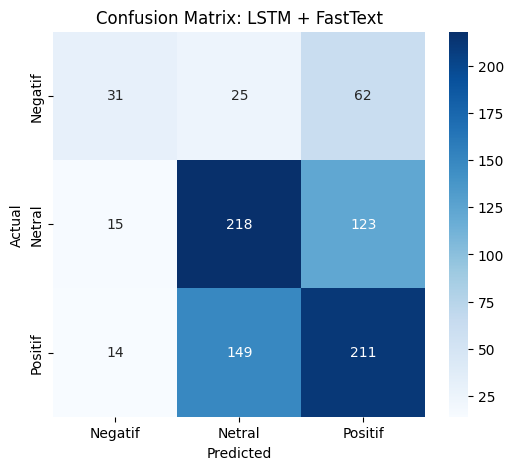

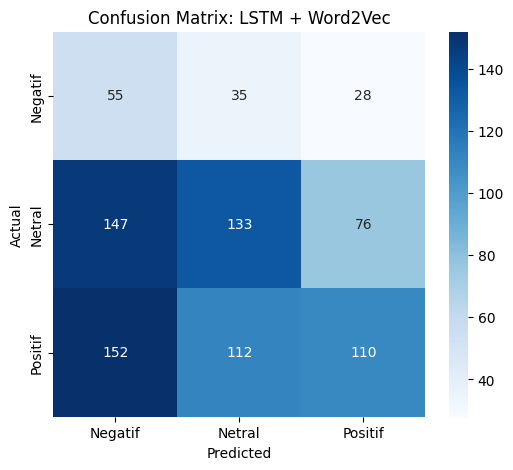

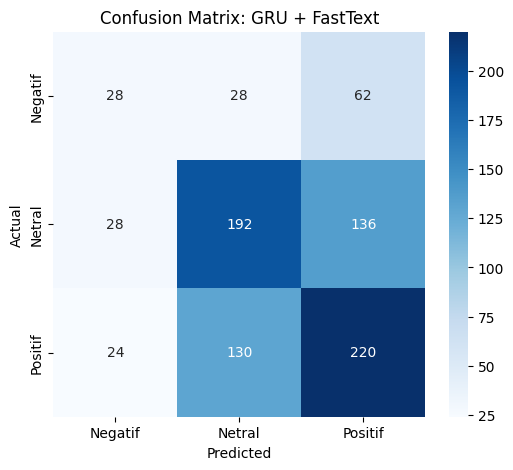

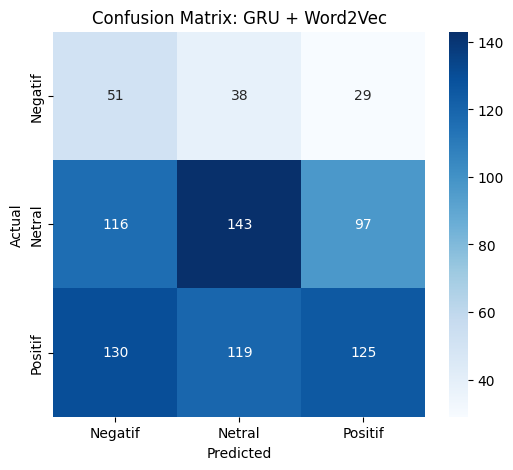

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Fungsi untuk plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# Misal label kita ada 3: Negatif, Netral, Positif
classes = ["Negatif", "Netral", "Positif"]

# Evaluasi dan visualisasi untuk masing-masing model
pred_lstm_ft  = evaluate_model(model_lstm_ft,  X_test, y_test, "LSTM + FastText")
pred_lstm_w2v = evaluate_model(model_lstm_w2v, X_test, y_test, "LSTM + Word2Vec")
pred_gru_ft   = evaluate_model(model_gru_ft,   X_test, y_test, "GRU + FastText")
pred_gru_w2v  = evaluate_model(model_gru_w2v,  X_test, y_test, "GRU + Word2Vec")

# Plot confusion matrix
plot_confusion_matrix(y_test_labels, pred_lstm_ft,  classes, "Confusion Matrix: LSTM + FastText")
plot_confusion_matrix(y_test_labels, pred_lstm_w2v, classes, "Confusion Matrix: LSTM + Word2Vec")
plot_confusion_matrix(y_test_labels, pred_gru_ft,   classes, "Confusion Matrix: GRU + FastText")
plot_confusion_matrix(y_test_labels, pred_gru_w2v,  classes, "Confusion Matrix: GRU + Word2Vec")

## Simpan Model

In [ ]:
import pickle
from google.colab import files

def save_model_pkl(model, tokenizer, name="model"):
    save_dict = {
        "model_json": model.to_json(),
        "model_weights": model.get_weights(),
        "tokenizer": tokenizer
    }
    with open(f"{name}.pkl", "wb") as f:
        pickle.dump(save_dict, f)

    print(f"Saved: {name}.pkl")

save_model_pkl(model_lstm_ft, tokenizer, "lstm_fasttext")
save_model_pkl(model_lstm_w2v, tokenizer, "lstm_word2vec")
save_model_pkl(model_gru_ft, tokenizer, "gru_fasttext")
save_model_pkl(model_gru_w2v, tokenizer, "gru_word2vec")

files.download("lstm_fasttext.pkl")
files.download("lstm_word2vec.pkl")
files.download("gru_fasttext.pkl")
files.download("gru_word2vec.pkl")

Saved: lstm_fasttext.pkl
Saved: lstm_word2vec.pkl
Saved: gru_fasttext.pkl
Saved: gru_word2vec.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>